# Test file for CICIDS2019 model creation and analysis

### 1. Data loading

In [13]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from datetime import datetime
from datetime import timedelta

pd.options.display.max_rows = 80

# Set the path to the folder containing the CSV files
#folder_path = '/mnt/AI-DATA/alara/CiberIA_O1/Data/01-12'  # Replace with your folder path

# Get a list of all CSV files in the folder
#csv_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.csv')]

#combined_df = None

#for i, file in enumerate(csv_files):
#    if i == 0:
#        # Read the first file with the header
#        print(f'Reading {file}')
#        combined_df = pd.read_csv(file)
#    else:
#        # Read subsequent files, skipping the header row
#        temp_df = pd.read_csv(file, skiprows=1, header=None)
#        temp_df.columns = combined_df.columns  # Assign the header from the first file
#        combined_df = pd.concat([combined_df, temp_df], ignore_index=True)
#        print(f'Combined {file}')

# Save the combined DataFrame to a new CSV file
#combined_df.to_csv('/mnt/AI-DATA/alara/CiberIA_O1/Data/CIC-DDoS2019.csv', index=False)

In [2]:
import pandas as pd
import os

# read data

df = pd.read_csv('/mnt/AI-DATA/alara/CiberIA_O1/Data/CIC-DDoS2019.csv')


/tmp/ipykernel_2921558/47492184.py:6: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/mnt/AI-DATA/alara/CiberIA_O1/Data/CIC-DDoS2019.csv')


### 2. Data exploration

In [3]:
from IPython.display import display
display(df.head())

,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,Label
0,21010,172.16.0.5-192.168.50.1-0-0-0,172.16.0.5,0,192.168.50.1,0,0,2018-12-01 11:22:40.254769,9141643,85894,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_LDAP
1,20932,172.16.0.5-192.168.50.1-900-1808-17,172.16.0.5,900,192.168.50.1,1808,17,2018-12-01 11:22:40.255361,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_LDAP
2,27876,172.16.0.5-192.168.50.1-900-58766-17,172.16.0.5,900,192.168.50.1,58766,17,2018-12-01 11:22:40.255568,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_LDAP
3,24270,172.16.0.5-192.168.50.1-900-35228-17,172.16.0.5,900,192.168.50.1,35228,17,2018-12-01 11:22:40.256113,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_LDAP
4,5109,172.16.0.5-192.168.50.1-900-44969-17,172.16.0.5,900,192.168.50.1,44969,17,2018-12-01 11:22:40.256285,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_LDAP


In [7]:
print('Cantidad de Filas y columnas:',df.shape)
print('Nombre columnas:',df.columns)

Cantidad de Filas y columnas: (70427637, 88)
Nombre columnas: Index(['Unnamed: 0', 'Flow ID', ' Source IP', ' Source Port',
       ' Destination IP', ' Destination Port', ' Protocol', ' Timestamp',
       ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Lengt

In [8]:
# elimina las columnas 0-7 y 85-86
df.drop(df.columns[0:8], axis=1, inplace=True)
df.drop(df.columns[85:87], axis=1, inplace=True)

# algunas columnas tienen el nombre un espacio al final o al principio, elimina los espacios
df.columns = df.columns.str.strip()

# convierte label a string
df['Label'] = df['Label'].astype(str)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70427637 entries, 0 to 70427636
Data columns (total 80 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Flow Duration                int64  
 1   Total Fwd Packets            int64  
 2   Total Backward Packets       int64  
 3   Total Length of Fwd Packets  float64
 4   Total Length of Bwd Packets  float64
 5   Fwd Packet Length Max        float64
 6   Fwd Packet Length Min        float64
 7   Fwd Packet Length Mean       float64
 8   Fwd Packet Length Std        float64
 9   Bwd Packet Length Max        float64
 10  Bwd Packet Length Min        float64
 11  Bwd Packet Length Mean       float64
 12  Bwd Packet Length Std        float64
 13  Flow Bytes/s                 float64
 14  Flow Packets/s               float64
 15  Flow IAT Mean                float64
 16  Flow IAT Std                 float64
 17  Flow IAT Max                 float64
 18  Flow IAT Min                 float64
 19

In [6]:
df.describe().transpose()

/home/alara/CiberIA_O1/env/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/alara/CiberIA_O1/env/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,70427637.0,9.002470e+04,1.158356e+05,0.0,21315.0,53685.0,105032.0,8.052440e+05
Source Port,70427637.0,3.176900e+04,2.633590e+04,0.0,876.0,36089.0,61850.0,6.553400e+04
Destination Port,70427637.0,3.283567e+04,1.890712e+04,0.0,16491.0,32844.0,49220.0,6.553500e+04
Protocol,70427637.0,1.590148e+01,3.298904e+00,0.0,17.0,17.0,17.0,1.700000e+01
Flow Duration,70427637.0,1.189558e+06,6.487063e+06,0.0,1.0,1.0,120.0,1.200000e+08
...,...,...,...,...,...,...,...,...
Idle Mean,70427637.0,1.707746e+05,1.762421e+06,0.0,0.0,0.0,0.0,1.192194e+08
Idle Std,70427637.0,4.909919e+04,6.060582e+05,0.0,0.0,0.0,0.0,6.961402e+07
Idle Max,70427637.0,2.276825e+05,2.337711e+06,0.0,0.0,0.0,0.0,1.192194e+08
Idle Min,70427637.0,1.245215e+05,1.385803e+06,0.0,0.0,0.0,0.0,1.192194e+08


### 3. Data cleaning

In [10]:
# Duplicate values
duplicates = df.duplicated()
print(f'There are {duplicates.sum()} duplicated rows in the dataset. Total shape: {df.shape}')
df.drop_duplicates(inplace=True)
print(f'Duplicated rows have been removed. New shape: {df.shape}')


There are 59577542 duplicated rows in the dataset. Total shape: (70427637, 80)
Duplicated rows have been removed. New shape: (10850095, 80)


In [11]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

Flow Bytes/s    144
dtype: int64


In [14]:
# Checking for infinity values
numeric_cols = df.select_dtypes(include = np.number).columns
inf_count = np.isinf(df[numeric_cols]).sum()
print(inf_count[inf_count > 0])

Flow Bytes/s      51496
Flow Packets/s    51640
dtype: int64


In [15]:
# Replacing any infinite values (positive or negative) with NaN (not a number)
print(f'Initial missing values: {df.isna().sum().sum()}')

df.replace([np.inf, -np.inf], np.nan, inplace = True)

print(f'Missing values after processing infinite values: {df.isna().sum().sum()}')

missing = df.isna().sum()
print(missing.loc[missing > 0])

Initial missing values: 144
Missing values after processing infinite values: 103280
Flow Bytes/s      51640
Flow Packets/s    51640
dtype: int64


In [16]:
# Calculating missing value percentage in the dataset
mis_per = (missing / len(df)) * 100
mis_table = pd.concat([missing, mis_per.round(2)], axis = 1)
mis_table = mis_table.rename(columns = {0 : 'Missing Values', 1 : 'Percentage of Total Values'})

print(mis_table.loc[mis_per > 0])

                Missing Values  Percentage of Total Values
Flow Bytes/s             51640                        0.48
Flow Packets/s           51640                        0.48


In [18]:
med_flow_bytes = df['Flow Bytes/s'].median()
med_flow_packets = df['Flow Packets/s'].median()

print('Median of Flow Bytes/s: ', med_flow_bytes)
print('Median of Flow Packets/s: ', med_flow_packets)

Median of Flow Bytes/s:  7321.755886875738
Median of Flow Packets/s:  20.26081750372546


In [19]:
# Filling missing values with median
df['Flow Bytes/s'].fillna(med_flow_bytes, inplace = True)
df['Flow Packets/s'].fillna(med_flow_packets, inplace = True)

print('Number of \'Flow Bytes/s\' missing values:', df['Flow Bytes/s'].isna().sum())
print('Number of \'Flow Packets/s\' missing values:', df['Flow Packets/s'].isna().sum())

Number of 'Flow Bytes/s' missing values: 0
Number of 'Flow Packets/s' missing values: 0


/tmp/ipykernel_2921558/4078083560.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Flow Bytes/s'].fillna(med_flow_bytes, inplace = True)
/tmp/ipykernel_2921558/4078083560.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [20]:
# save to csv
df.to_csv('/mnt/AI-DATA/alara/CiberIA_O1/Data/CIC-DDoS2019_clean.csv', index = False)

In [21]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from datetime import datetime
from datetime import timedelta

pd.options.display.max_rows = 80

# read data

df = pd.read_csv('/mnt/AI-DATA/alara/CiberIA_O1/Data/CIC-DDoS2019.csv')

/tmp/ipykernel_2921558/3623673425.py:14: DtypeWarning: Columns (77) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/mnt/AI-DATA/alara/CiberIA_O1/Data/CIC-DDoS2019.csv')


### 4. Data visualization


In [22]:
df['Label'].value_counts()

Label
TFTP             4578741
UDP              1343167
DrDoS_UDP        1127468
DrDoS_NTP        1116430
DrDoS_SSDP        925675
Syn               689387
MSSQL             290470
DrDoS_MSSQL       241763
DrDoS_SNMP        129225
DrDoS_DNS         127986
BENIGN             96546
UDP-lag            90542
DrDoS_LDAP         35263
DrDoS_NetBIOS      23732
LDAP               19657
NetBIOS            11428
Portmap             1743
UDPLag               455
WebDDoS              417
Name: count, dtype: int64

In [23]:
# Creating a new column 'Attack Type' in the DataFrame based on the attack_map dictionary
df['Attack Type'] = df['Label']
df['Attack Type'].value_counts()
df.drop('Label', axis = 1, inplace = True)

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Attack Number'] = le.fit_transform(df['Attack Type'])

encoded_values = df['Attack Number'].unique()
for val in sorted(encoded_values):
    print(f"{val}: {le.inverse_transform([val])[0]}")

0: BENIGN
1: DrDoS_DNS
2: DrDoS_LDAP
3: DrDoS_MSSQL
4: DrDoS_NTP
5: DrDoS_NetBIOS
6: DrDoS_SNMP
7: DrDoS_SSDP
8: DrDoS_UDP
9: LDAP
10: MSSQL
11: NetBIOS
12: Portmap
13: Syn
14: TFTP
15: UDP
16: UDP-lag
17: UDPLag
18: WebDDoS


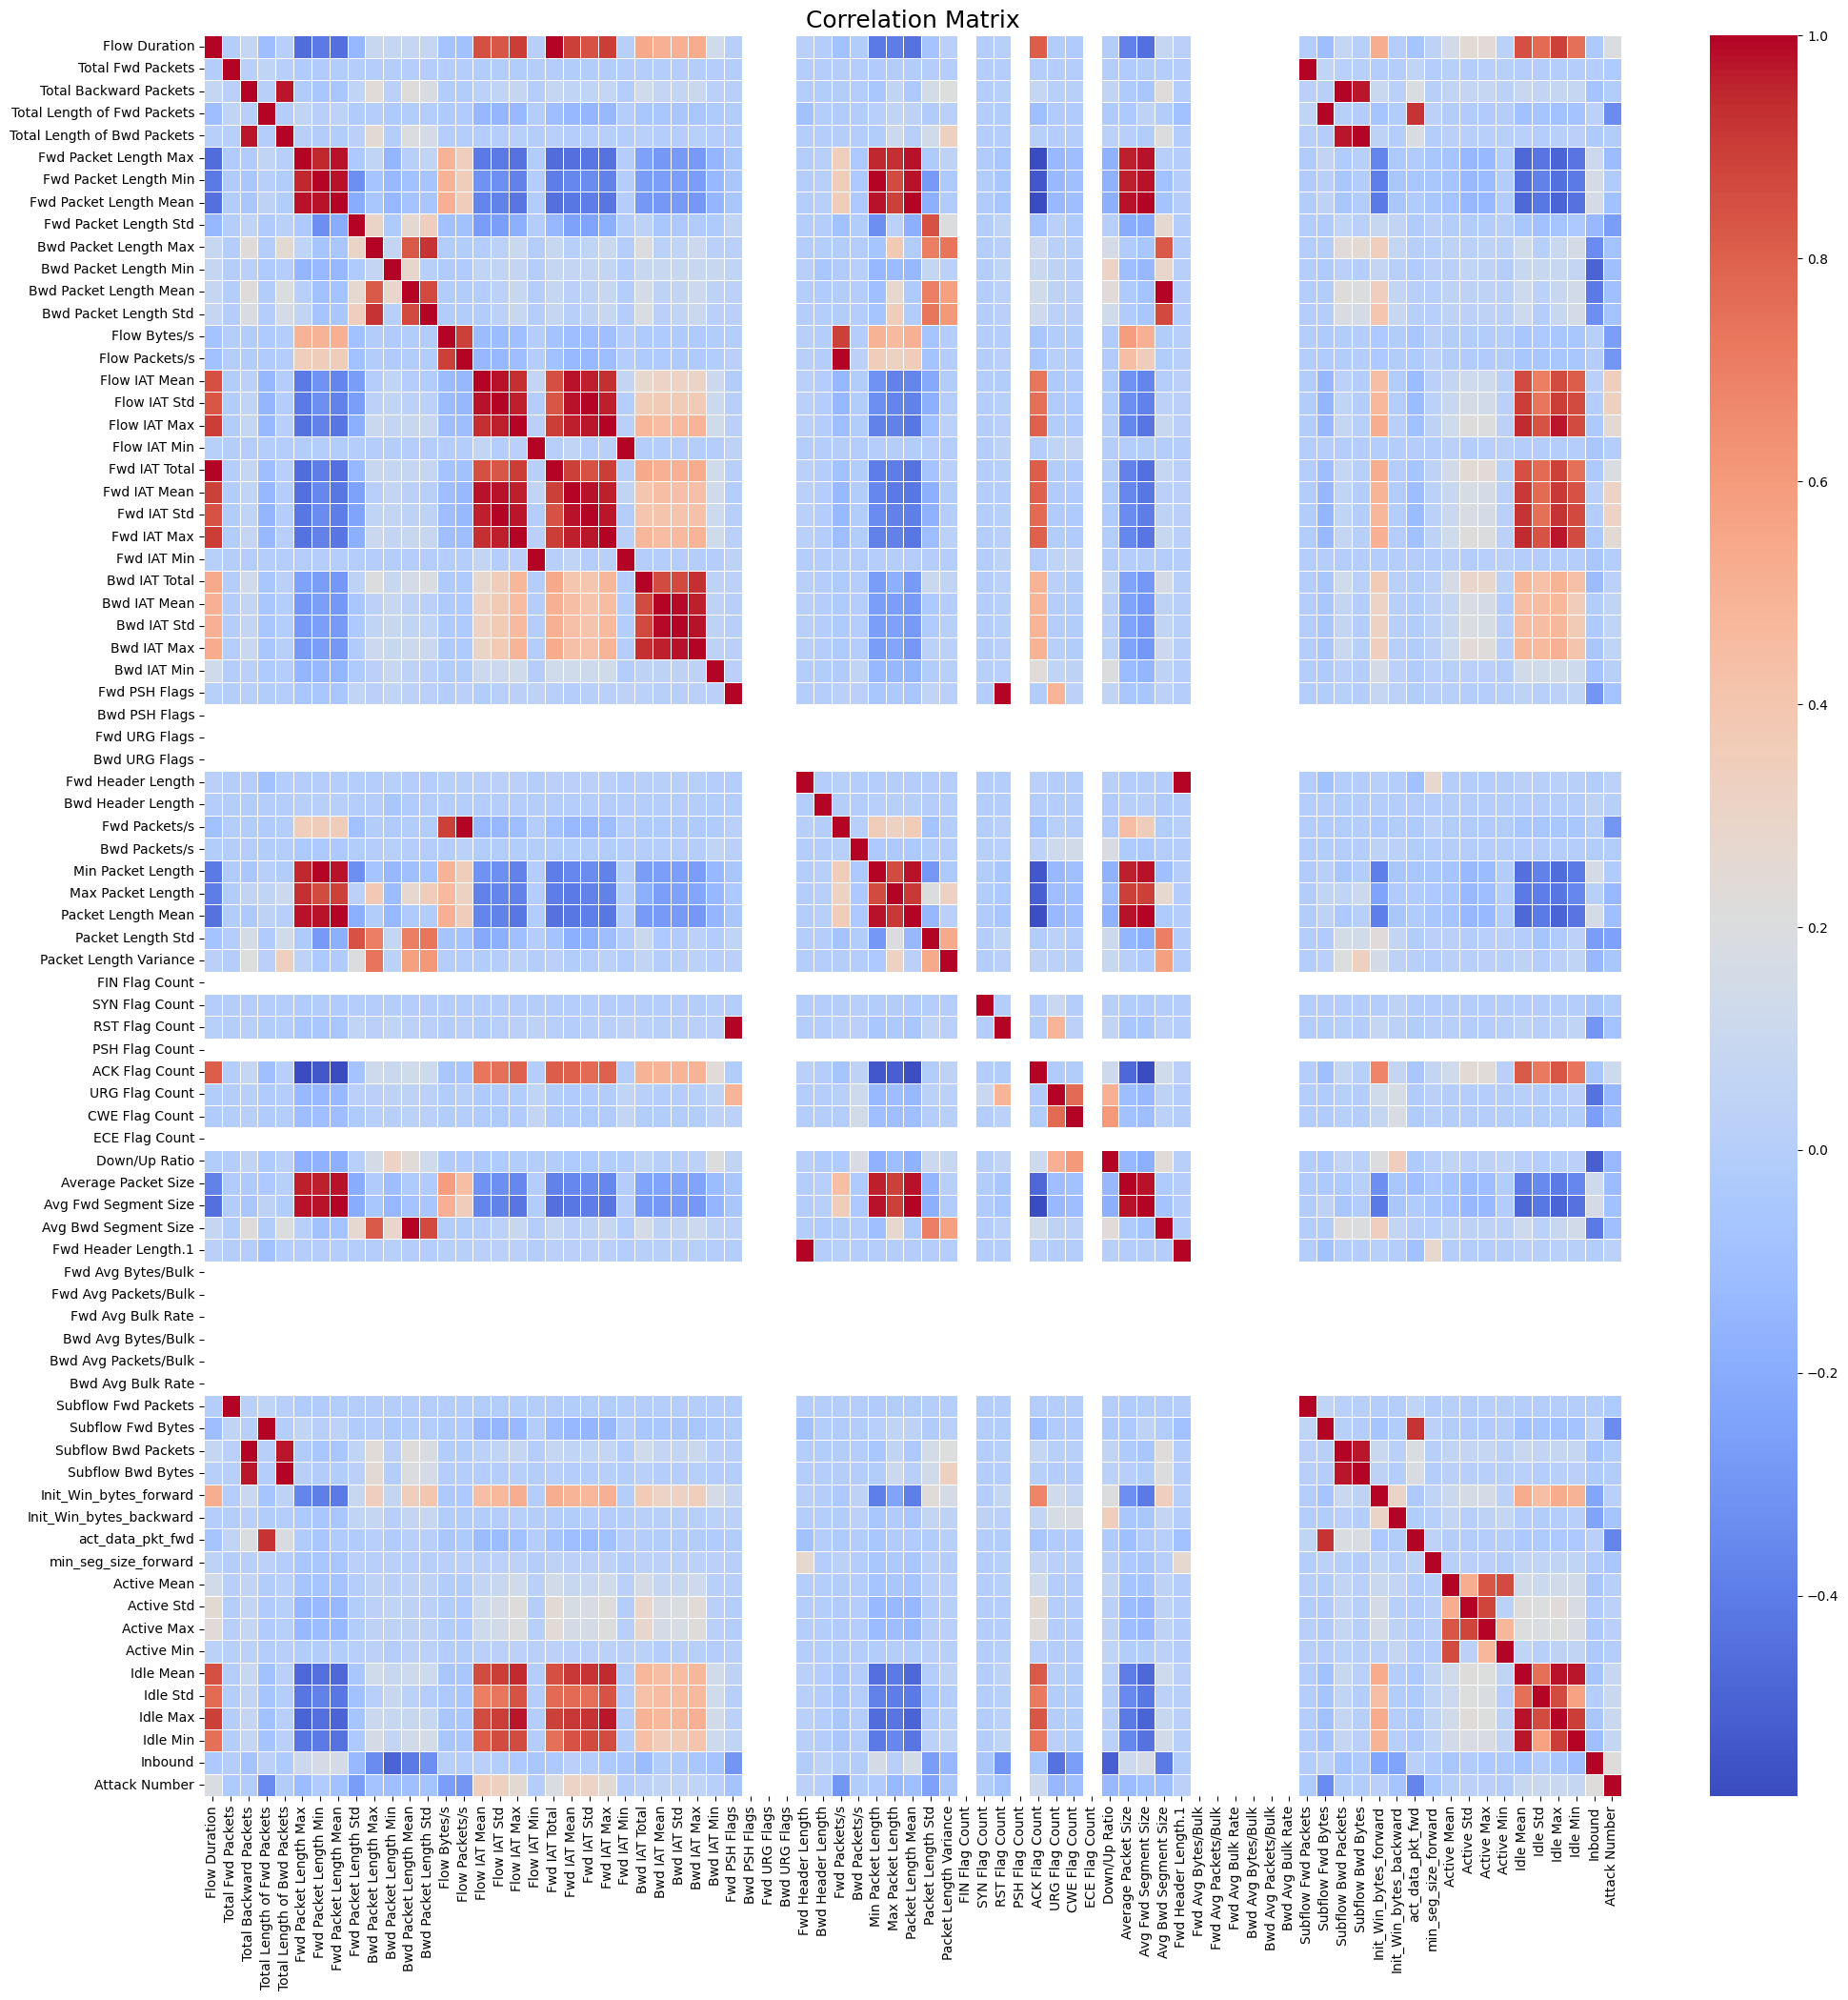

In [25]:
corr = df.corr(numeric_only = True).round(2)
corr.style.background_gradient(cmap = 'coolwarm', axis = None).format(precision = 2)

fig, ax = plt.subplots(figsize = (24, 24))
sns.heatmap(corr, cmap = 'coolwarm', annot = False, linewidth = 0.5)
plt.title('Correlation Matrix', fontsize = 18)
plt.show()

In [26]:
pos_corr_features = corr['Attack Number'][(corr['Attack Number'] > 0) & (corr['Attack Number'] < 1)].index.tolist()
# ordenador por valor absoluto
pos_corr_features.sort(key = lambda x: abs(corr.loc[x, 'Attack Number']), reverse = True)

print("Features with positive correlation with 'Attack Number':\n")
for i, feature in enumerate(pos_corr_features, start = 1):
    corr_value = corr.loc[feature, 'Attack Number']
    print('{:<3} {:<24} :{}'.format(f'{i}.', feature, corr_value))

print(f'Number of considerable important features: {len(pos_corr_features)}')

Features with positive correlation with 'Attack Number':

1.  Flow IAT Mean            :0.34
2.  Flow IAT Std             :0.33
3.  Fwd IAT Mean             :0.31
4.  Fwd IAT Std              :0.31
5.  Flow IAT Max             :0.25
6.  Fwd IAT Max              :0.25
7.  Inbound                  :0.22
8.  Flow Duration            :0.19
9.  Fwd IAT Total            :0.19
10. ACK Flag Count           :0.12
11. Idle Std                 :0.1
12. Idle Max                 :0.1
13. Idle Mean                :0.09
14. Idle Min                 :0.08
15. Bwd IAT Mean             :0.06
16. Bwd IAT Std              :0.05
17. Bwd IAT Max              :0.05
18. Bwd IAT Total            :0.03
19. Fwd Header Length        :0.03
20. Fwd Header Length.1      :0.03
21. Active Std               :0.03
22. Init_Win_bytes_forward   :0.02
23. Active Max               :0.02
24. Bwd IAT Min              :0.01
25. Bwd Header Length        :0.01
26. Active Mean              :0.01
Number of considerable important f

/tmp/ipykernel_2921558/2043510913.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = 'Attack Type', data = attacks, palette = 'pastel', order = attacks['Attack Type'].value_counts().index)


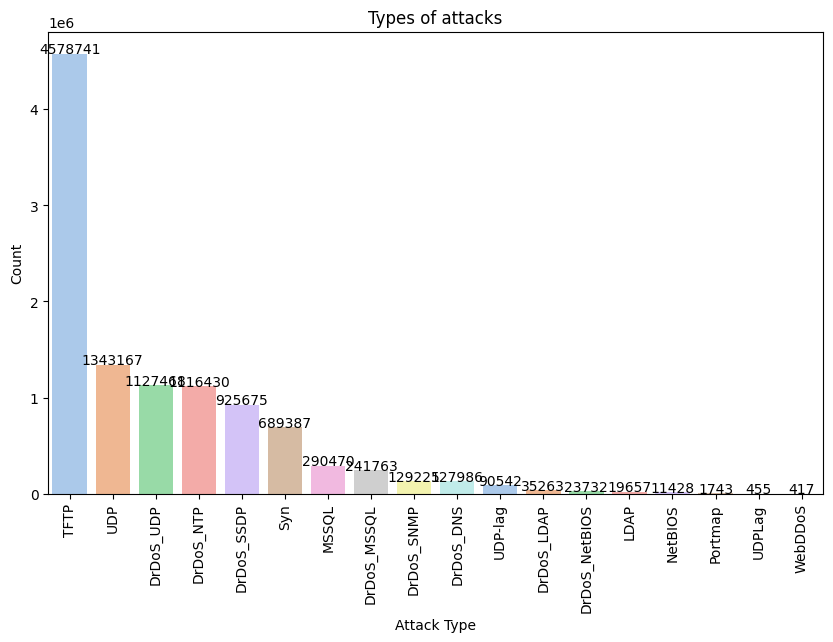

In [27]:
# Different 'Attack Type' in the main dataset excluding 'BENIGN'
attacks = df.loc[df['Attack Type'] != 'BENIGN']

plt.figure(figsize = (10, 6))
ax = sns.countplot(x = 'Attack Type', data = attacks, palette = 'pastel', order = attacks['Attack Type'].value_counts().index)
plt.title('Types of attacks')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation = 90)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2, p.get_height() + 1000), ha = 'center')

plt.show()

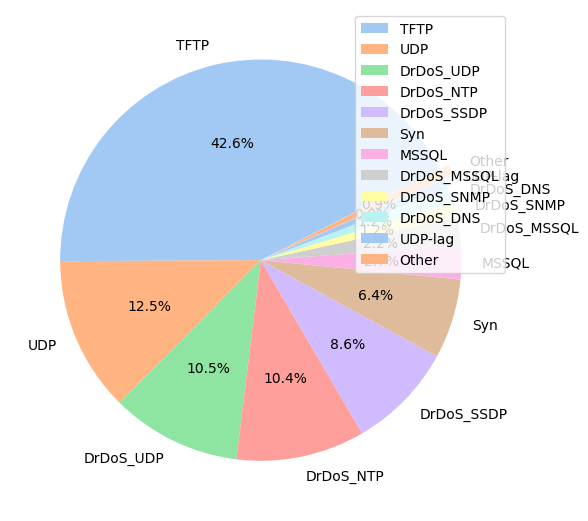

In [28]:
# Calculate attack type distribution
attack_counts = attacks['Attack Type'].value_counts()
threshold = 0.005
percentages = attack_counts / attack_counts.sum()
small_slices = percentages[percentages < threshold].index.tolist()

# Combine small categories into 'Other'
if small_slices:
    other_sum = attack_counts[small_slices].sum()
    attack_counts = attack_counts.drop(small_slices)
    attack_counts['Other'] = other_sum

# Plot settings
sns.set_palette('pastel')
plt.figure(figsize=(6,6))

# Improved labels with clearer formatting
explode = [0.05 if label == 'Other' else 0 for label in attack_counts.index]
plt.pie(
    attack_counts.values, 
    labels=attack_counts.index, 
    autopct='%1.1f%%', 
    textprops={'fontsize': 10},
    explode=explode,
    startangle=387
)

# Title and legend adjustments
plt.legend(attack_counts.index, loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig('attack_distribution.png',dpi=500)
plt.show()


### 5. Data preprocessing

In [29]:
# For improving performance and reduce memory-related errors
old_memory_usage = df.memory_usage().sum() / 1024 ** 2
print(f'Initial memory usage: {old_memory_usage:.2f} MB')
for col in df.columns:
    col_type = df[col].dtype
    if col_type != object:
        c_min = df[col].min()
        c_max = df[col].max()
        # Downcasting float64 to float32
        if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
            df[col] = df[col].astype(np.float32)

        # Downcasting int64 to int32
        elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
            df[col] = df[col].astype(np.int32)

new_memory_usage = df.memory_usage().sum() / 1024 ** 2
print(f"Final memory usage: {new_memory_usage:.2f} MB")

# Calculating percentage reduction in memory usage
print(f'Reduced memory usage: {1 - (new_memory_usage / old_memory_usage):.2%}')

Initial memory usage: 6705.15 MB
Final memory usage: 3559.53 MB
Reduced memory usage: 46.91%


In [30]:
# Dropping columns with only one unique value
num_unique = df.nunique()
one_variable = num_unique[num_unique == 1]
not_one_variable = num_unique[num_unique > 1].index

dropped_cols = one_variable.index
data = df[not_one_variable]

print('Dropped columns:')
dropped_cols

Dropped columns:


Index(['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'FIN Flag Count',
       'PSH Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk',
       'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk',
       'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate'],
      dtype='object')

In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10850095 entries, 0 to 10850094
Data columns (total 69 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Flow Duration                int32  
 1   Total Fwd Packets            int32  
 2   Total Backward Packets       int32  
 3   Total Length of Fwd Packets  float32
 4   Total Length of Bwd Packets  float32
 5   Fwd Packet Length Max        float32
 6   Fwd Packet Length Min        float32
 7   Fwd Packet Length Mean       float32
 8   Fwd Packet Length Std        float32
 9   Bwd Packet Length Max        float32
 10  Bwd Packet Length Min        float32
 11  Bwd Packet Length Mean       float32
 12  Bwd Packet Length Std        float32
 13  Flow Bytes/s                 float32
 14  Flow Packets/s               float32
 15  Flow IAT Mean                float32
 16  Flow IAT Std                 float32
 17  Flow IAT Max                 float32
 18  Flow IAT Min                 float32
 19

In [32]:
# save only numerical data
attacks = data['Attack Type']
data = data.select_dtypes(include = ['float32', 'int32'])

#### PCA

In [52]:
# Standardizing the dataset
from sklearn.preprocessing import StandardScaler

features = data

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

from sklearn.decomposition import IncrementalPCA

size = len(features.columns) // 2
ipca = IncrementalPCA(n_components = size, batch_size = 500)
for batch in np.array_split(scaled_features, len(features) // 500):
    ipca.partial_fit(batch)

print(f'information retained: {sum(ipca.explained_variance_ratio_):.2%}')

transformed_features = ipca.transform(scaled_features)
new_data_pca = pd.DataFrame(transformed_features, columns = [f'PC{i+1}' for i in range(size)])
new_data_pca['Attack Type'] = attacks.values

new_data_pca

information retained: 99.45%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,Attack Type
0,-2.509368,0.203272,-0.039310,-0.140706,0.322799,0.671007,1.305862,0.419530,-0.803705,0.299363,...,0.159135,-0.133117,0.011667,0.225158,-0.812696,-1.553432,-1.296031,-1.512617,0.555685,BENIGN
1,-2.516422,0.144865,-0.065418,-0.166519,0.270772,0.324362,0.284526,0.550880,-0.958530,0.308537,...,0.170621,-0.092107,-0.219102,0.363457,-0.836991,-1.549648,-1.343860,-1.547885,0.578635,BENIGN
2,-0.966698,0.018119,2.855750,8.034159,-7.327015,-1.665551,1.940824,0.391759,5.465520,-3.993218,...,7.561811,6.082503,1.289755,1.258285,0.786977,-0.805557,-0.447590,0.275247,1.535531,BENIGN
3,-2.516422,0.144865,-0.065418,-0.166519,0.270772,0.324362,0.284526,0.550880,-0.958530,0.308537,...,0.170621,-0.092107,-0.219102,0.363457,-0.836991,-1.549648,-1.343860,-1.547885,0.578635,BENIGN
4,-2.511668,0.285839,-0.051204,-0.151460,0.298562,0.506276,0.851430,0.387441,-0.882854,0.301419,...,0.164956,-0.113633,-0.124680,0.308024,-0.822520,-1.543230,-1.321139,-1.526074,0.561351,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15799743,-2.427846,0.203337,-0.655857,-1.795190,1.610823,-0.459570,0.066752,0.879211,-0.523421,-0.337499,...,-0.328718,0.796270,0.053019,0.327983,0.828248,-0.018273,0.200507,0.001604,-0.142658,BENIGN
15799744,-2.705072,0.006397,-0.425861,-1.205846,1.217289,-0.110443,-0.015562,-0.001755,-0.476788,-0.025604,...,-0.210688,0.755842,0.075233,-0.066842,0.503496,-0.052264,-0.082005,-0.148183,-0.075134,BENIGN
15799745,-2.153055,-0.006421,0.857824,2.413961,-1.876197,-0.142057,-0.085075,0.023585,0.223195,-0.087272,...,-0.179327,-0.154124,-0.013190,0.004965,0.011276,-0.030663,-0.012176,0.155531,-0.023546,BENIGN
15799746,4.534169,-0.050910,-0.488450,-0.797236,-0.255090,-1.397870,0.448083,0.178389,-0.085633,-0.530006,...,-0.670316,0.710851,0.154866,0.052212,-0.044953,0.222755,0.029873,-0.015949,0.051351,BENIGN


In [33]:
# select k best features
from sklearn.feature_selection import SelectKBest, f_classif

features = data
target = attacks

k = 20
selector = SelectKBest(f_classif, k = k)
selector.fit(features, target)

selected_features = features.columns[selector.get_support()]
selected_features

print(f'Selected Features: {selected_features}')

# save selected features
new_data_k_20 = data[selected_features]
new_data_k_20['Attack Type'] = attacks.values

k = 40
selector = SelectKBest(f_classif, k = k)
selector.fit(features, target)

selected_features = features.columns[selector.get_support()]
selected_features

print(f'Selected Features: {selected_features}')

# save selected features
new_data_k_40 = data[selected_features]
new_data_k_40['Attack Type'] = attacks.values

/home/alara/CiberIA_O1/env/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/tmp/ipykernel_2705846/1773033171.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data_k_20['Attack Type'] = attacks.values


Selected Features: Index(['Dst Port', 'Flow Duration', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Flow Bytes/s',
       'Flow Packets/s', 'Fwd IAT Total', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'FIN Flag Count', 'Down/Up Ratio',
       'Average Packet Size', 'Fwd Segment Size Avg', 'Fwd Seg Size Min',
       'Active Mean', 'Active Std', 'Active Max', 'Attack Number'],
      dtype='object')
Selected Features: Index(['Dst Port', 'Flow Duration', 'Total Length of Fwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Bwd IAT Total',
       'Bwd IAT Mean', 'Bwd IAT Std', 'Fwd Packets/s', 'Bwd Packets/s',
    

/home/alara/CiberIA_O1/env/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/tmp/ipykernel_2705846/1773033171.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data_k_40['Attack Type'] = attacks.values
